# Analyse following simultaneously to find any pattern (in progress):  
1. Find synchronisation core

#### Progress:
- 1st node in main cluster enters at 175 timestep and large number of nodes starts entering  main cluster at around 3299. This justifies that why there is rise in global order initially but not visible while plotting node community matrix
- Print only if node entries changes

- Plot number of nodes entering with timestep
- Compare above plots
- On comparing by superimposing, nothing meaningful can be inferred

#### To do:
- Find influential node
- Storing all node sets and find if there is a common node set which persists



In [2]:
%reload_ext autoreload
%autoreload 2


from tes.data_ingestion import DataRead

from tes.analysis import AnalysisFunc

from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import TwoSlopeNorm
import pandas as pd
import numpy as np


#### Create objects


In [3]:
reader=DataRead()
analyse=AnalysisFunc()

#### Load data

In [4]:
df_itr=reader.data_read_bz2('raw/FN/itr_200.bz2')
# df_loc = reader.data_read_bz2('raw/test/loc_test.bz2')
df_nc = reader.data_read_bz2('raw/FN/nc_200.bz2')

#### Running analysis to get itration for analysis

In [5]:
param=analyse.compute_param(df_itr,0.05)

Number of transitions / 100 iteration [0, 58, 128]
Number of transition [2, 3, 6, 7, 10, 11, 14, 15, 20, 23, 25, 26, 27, 29, 31, 33, 35, 37, 39, 40, 42, 44, 47, 50, 51, 53, 55, 57, 58, 60, 61, 63, 64, 66, 67, 68, 71, 72, 73, 76, 77, 79, 81, 82, 83, 85, 87, 88, 89, 90, 93, 95, 97, 98, 105, 106, 107, 110, 113, 115, 117, 118, 120, 121, 123, 127, 129, 131, 135, 136, 137, 138, 139, 140, 142, 143, 145, 147, 149, 150, 152, 156, 157, 158, 159, 162, 163, 164, 167, 168, 169, 170, 171, 172, 174, 175, 176, 180, 182, 183, 185, 186, 191, 193, 194, 196, 197, 199]
Number of transition with more than one transition or a fall back [2, 11, 14, 23, 29, 50, 51, 53, 77, 83, 87, 90, 95, 98, 107, 120, 123, 129, 135, 136, 140, 145, 147, 162, 170, 171, 174, 185, 193, 199]


#### Superimposing plots at node count = 100 to see if there really exists a pattern

In [6]:
df_r=df_nc.reset_index(drop=True)

In [7]:
df_r.shape

(640000, 426)

#### Using node count function to compute node entering main cluster at times when this count changes

In [8]:
i=0
f=5000
time_list=[]
node_count_list=[]
while f < df_r.shape[0]:
    l=analyse.node_count(df_r.iloc[i:f,:])
    time_list.append(l['timestep'])
    node_count_list.append(l['node_count'])
    i=f
    f+=5000

In [26]:
nc_df=pd.DataFrame(node_count_list).T
nc_df

,0,1,2,3,4,5,6,7,8,9,...,78,79,80,81,82,83,84,85,86,87
0,2.0,1.0,4.0,1.0,1.0,1.0,4.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,222.0,26.0,1.0,1.0,1.0,18.0
1,1.0,1.0,2.0,1.0,1.0,1.0,3.0,1.0,1.0,1.0,...,1.0,1.0,2.0,1.0,223.0,25.0,1.0,1.0,1.0,19.0
2,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,2.0,1.0,220.0,26.0,1.0,1.0,1.0,20.0
3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,...,1.0,1.0,4.0,1.0,219.0,27.0,1.0,1.0,2.0,18.0
4,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,3.0,1.0,...,1.0,1.0,6.0,1.0,218.0,28.0,5.0,1.0,3.0,17.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2341,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,272.0,NaN,NaN,NaN,NaN,NaN
2342,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,268.0,NaN,NaN,NaN,NaN,NaN
2343,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,270.0,NaN,NaN,NaN,NaN,NaN
2344,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,268.0,NaN,NaN,NaN,NaN,NaN


In [27]:
time_df=pd.DataFrame(time_list).T
time_df

,0,1,2,3,4,5,6,7,8,9,...,78,79,80,81,82,83,84,85,86,87
0,0.0,0.0,0.0,0.0,52.0,0.0,0.0,0.0,0.0,0.0,...,19.0,0.0,3131.0,30.0,0.0,0.0,0.0,3.0,3237.0,0.0
1,10.0,1.0,11.0,28.0,53.0,6.0,3.0,5.0,4.0,8.0,...,99.0,37.0,3138.0,31.0,4.0,1.0,20.0,49.0,3245.0,1.0
2,13.0,10.0,14.0,34.0,68.0,23.0,6.0,8.0,14.0,21.0,...,110.0,42.0,3140.0,41.0,5.0,3.0,37.0,53.0,3246.0,5.0
3,15.0,31.0,33.0,94.0,74.0,104.0,7.0,10.0,20.0,22.0,...,111.0,49.0,3141.0,540.0,8.0,4.0,49.0,61.0,3248.0,7.0
4,30.0,66.0,54.0,106.0,76.0,107.0,8.0,27.0,28.0,46.0,...,117.0,62.0,3143.0,824.0,9.0,5.0,73.0,116.0,3251.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2341,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,4995.0,NaN,NaN,NaN,NaN,NaN
2342,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,4996.0,NaN,NaN,NaN,NaN,NaN
2343,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,4997.0,NaN,NaN,NaN,NaN,NaN
2344,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,4998.0,NaN,NaN,NaN,NaN,NaN


#### Plot node count entering at every timestep

Text(0.5, 1.0, 'node count in. main cluster')

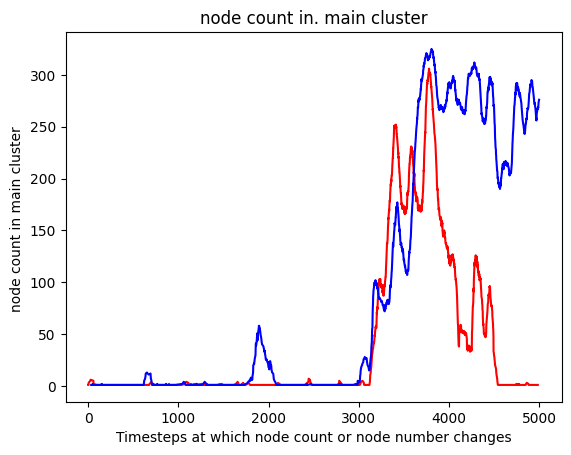

In [10]:
plt.plot(time_df[0],nc_df[0],color='r')
plt.plot(time_df[1],nc_df[1],color='b')
plt.xlabel('Timesteps at which node count or node number changes')
plt.ylabel('node count in main cluster ')
plt.title('node count in. main cluster')

We can also plot node count only above.

Text(0.5, 1.0, 'node count in. main cluster')

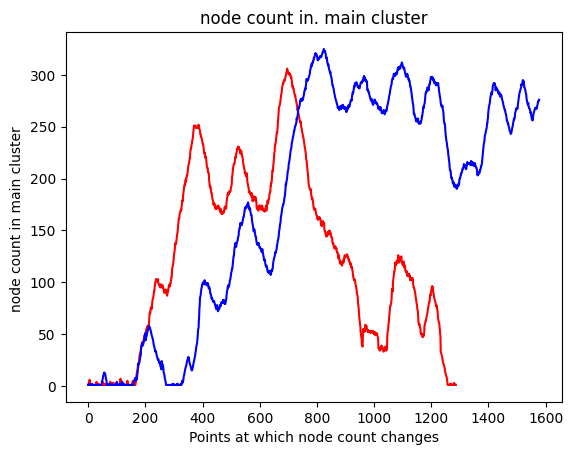

In [11]:

plt.plot(range(0,nc_df[0].shape[0]),nc_df[0],color='r')
plt.plot(range(0,nc_df[1].shape[0]),nc_df[1],color='b')
plt.xlabel('Points at which node count changes')
plt.ylabel('node count in main cluster ')
plt.title('node count in. main cluster')

#### Define the function for overlapping

In [9]:
def plot_nc_overlap(nc_df,name):
    df_check=nc_df.apply(lambda c: c>=100)
    
    set_point = 500
    c=0
    for i in range(0,df_check.shape[1]):
        for val in df_check[i]:
            
            c+=1
            if val == True:
                ts=c
                c=0
                break
        x=list(range(0,nc_df[i].shape[0]))
        
        if ts-1>set_point:
            # time_df[i].dropna(inplace=True)
            # nc_df[i].dropna(inplace=True)
            
            plt.plot(x,nc_df[i].shift(-(ts-set_point)),color=cm.Blues(0.8, 0.05), lw=1.5)
            plt.grid()
        else:
            # time_df[i].dropna(inplace=True)
            # nc_df[i].dropna(inplace=True)
            plt.plot(x,nc_df[i].shift(set_point-ts),color=cm.Blues(0.8, 0.05), lw=1.5)
            plt.grid()
        i+=1
    
    plt.xlabel("timestep")
    plt.ylabel("Node count")
    plt.title(name)
#plt.savefig('../../data/results/PIR_node_count.png')

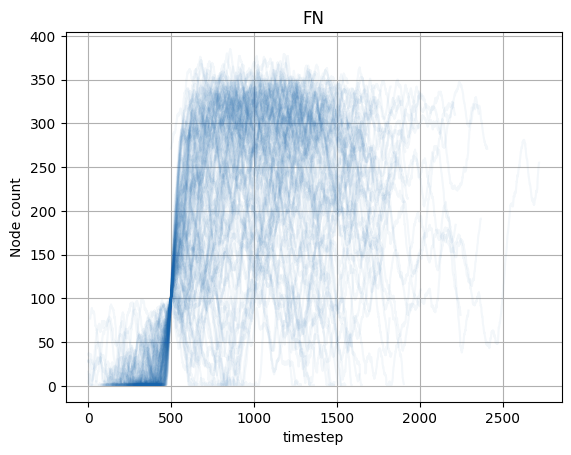

In [11]:
plot_nc_overlap(nc_df,'FN')

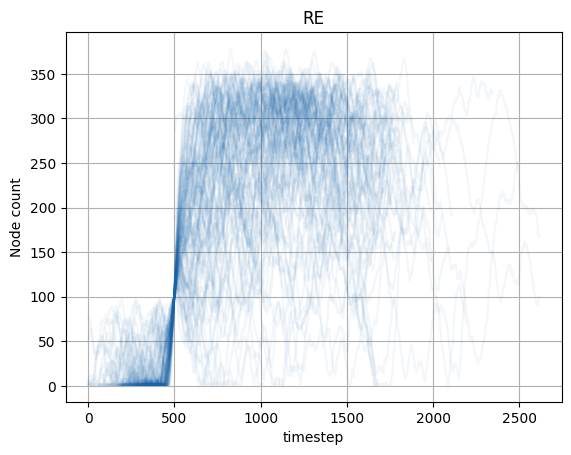

In [20]:
plot_nc_overlap(nc_df,'RE')

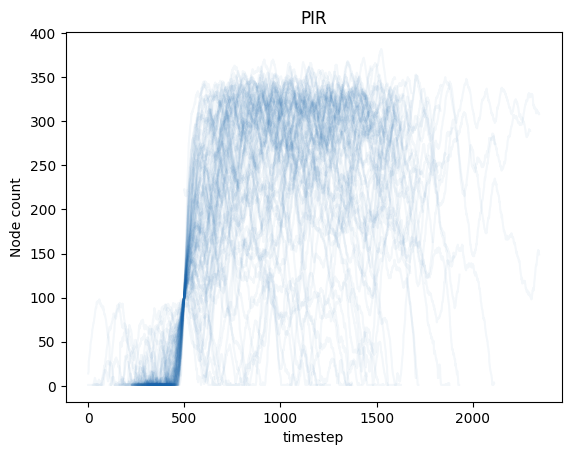

In [31]:
plot_nc_overlap(nc_df,'PIR')

From above, nothing meaningful after overlapping signals

#### Let's try some ML technique if any for identifying the sequence

In [10]:
#let's see if node list is calculated how
#df_nc.loc[2]
nl=analyse.node_count(df_nc.loc[2])
node_list=nl['node_list']


In [11]:
nl.keys()

dict_keys(['node_count', 'timestep', 'node_list'])

In [12]:
len(node_list)

1287

#### Algorithm to find probability of nodes pulling other nodes

In [13]:
len(nl['node_count'])

1287

In [16]:
# defining test case to check for algorithm
test_list=[[1],[1, 2], [1,4,3],[2,5],[1,2,3]]
print(test_list)

[[1], [1, 2], [1, 4, 3], [2, 5], [1, 2, 3]]


In [25]:
# defining network nodes list
network_nodes = list(range(1, 5))

# use node_count function to extract node lists
# nl=analyse.node_count(df_nc.loc[2])
# node_list=nl['node_list']
num_matrix = np.zeros((5,5))
den_matrix = np.zeros((5,5))

for n in network_nodes:
    comp_list=network_nodes
    comp_list.pop(n-1)
    for m in comp_list:
        for id, case in enumerate(test_list):
            if n in case and m not in case:
                if id+1 != len(test_list):
                    if n in test_list[id+1] and m in test_list[id+1]:
                        num_matrix[n, m]+=1
                        den_matrix[n,m]+=1
                    else:
                        den_matrix[n,m]+=1
                else:
                    break
            else:
                continue


print(num_matrix)
print(den_matrix)
            
                    
                
        
        
        


[[0. 0. 0. 0. 0.]
 [0. 0. 1. 1. 1.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]
[[0. 0. 0. 0. 0.]
 [0. 0. 2. 2. 2.]
 [0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0.]]


In [23]:
den_matrix

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 2., 2.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]])

In [21]:
l=[1,2,3,4]
m=l.remove(3)
print(m)


None
